# **How to Start Project**
* conda deactivate
* conda create -n ml_summer_course python=3.11
* conda activate ml_summer_course
* pip install ipykernel
==========================================
##### Github Push
- git config --global user.name "XYZ"
- git config --global user.email "XYZ@example.com"


## **ML Life Cycle** 
![Room Occupancy Dataset](img2.png)

# **Library**

In [24]:
# EDA Library 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math


# **Room Occupancy Estimation Data Set**
##### Kaggle Link : https://www.kaggle.com/datasets/ananthr1/room-occupancy-estimation-data-set?utm_source=chatgpt.com
![Room Occupancy Dataset](img1.png)

# **1 - Data Understanding**

In [2]:
# Read Data 
data = pd.read_csv(r'F:\Programming\ECU\Summer Course 2025\Subjects\ML Course\Dataset\Occupancy_Estimation.csv')
df = data.copy()
df.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [3]:
# Random Data
df.sample(5)


,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
1656,2017/12/23,01:41:09,25.31,25.31,24.88,25.75,0,0,0,0,0.07,0.05,0.06,0.06,370,0.000000,0,0,0
2584,2017/12/23,09:41:06,25.06,25.06,24.63,25.38,7,8,39,26,0.08,0.05,0.07,0.06,360,-0.015385,0,0,0
9327,2018/01/11,02:07:06,25.19,25.19,24.75,25.25,0,0,0,0,0.07,0.04,0.05,0.09,345,0.000000,0,0,0
6734,2017/12/25,21:32:02,25.38,25.44,25.06,25.88,0,0,0,0,0.07,0.06,0.06,0.10,355,0.073077,0,0,0
56,2017/12/22,11:18:17,25.25,24.94,24.81,25.63,123,35,59,45,0.68,0.12,0.11,0.10,430,0.842308,0,0,1


In [4]:
# size of the dataset
df.shape    

(10129, 19)

In [5]:
# Data Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  10129 non-null  str    
 1   Time                  10129 non-null  str    
 2   S1_Temp               10129 non-null  float64
 3   S2_Temp               10129 non-null  float64
 4   S3_Temp               10129 non-null  float64
 5   S4_Temp               10129 non-null  float64
 6   S1_Light              10129 non-null  int64  
 7   S2_Light              10129 non-null  int64  
 8   S3_Light              10129 non-null  int64  
 9   S4_Light              10129 non-null  int64  
 10  S1_Sound              10129 non-null  float64
 11  S2_Sound              10129 non-null  float64
 12  S3_Sound              10129 non-null  float64
 13  S4_Sound              10129 non-null  float64
 14  S5_CO2                10129 non-null  int64  
 15  S5_CO2_Slope          10129 no

In [6]:
df.columns

Index(['Date', 'Time', 'S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light',
       'S2_Light', 'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound',
       'S4_Sound', 'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR',
       'Room_Occupancy_Count'],
      dtype='str')

In [7]:
# Check Description of the dataset
df.describe()

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
count,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.00000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000
mean,25.454012,25.546059,25.056621,25.754125,25.445059,26.01629,34.248494,13.220259,0.168178,0.120066,0.158119,0.103840,460.860401,-0.004830,0.090137,0.079574,0.398559
std,0.351351,0.586325,0.427283,0.356434,51.011264,67.30417,58.400744,19.602219,0.316709,0.266503,0.413637,0.120683,199.964940,1.164990,0.286392,0.270645,0.893633
min,24.940000,24.750000,24.440000,24.940000,0.000000,0.00000,0.000000,0.000000,0.060000,0.040000,0.040000,0.050000,345.000000,-6.296154,0.000000,0.000000,0.000000
25%,25.190000,25.190000,24.690000,25.440000,0.000000,0.00000,0.000000,0.000000,0.070000,0.050000,0.060000,0.060000,355.000000,-0.046154,0.000000,0.000000,0.000000
50%,25.380000,25.380000,24.940000,25.750000,0.000000,0.00000,0.000000,0.000000,0.080000,0.050000,0.060000,0.080000,360.000000,0.000000,0.000000,0.000000,0.000000
75%,25.630000,25.630000,25.380000,26.000000,12.000000,14.00000,50.000000,22.000000,0.080000,0.060000,0.070000,0.100000,465.000000,0.000000,0.000000,0.000000,0.000000
max,26.380000,29.000000,26.190000,26.560000,165.000000,258.00000,280.000000,74.000000,3.880000,3.440000,3.670000,3.400000,1270.000000,8.980769,1.000000,1.000000,3.000000


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
S1_Temp,10129.0,25.454012,0.351351,24.940000,25.190000,25.38,25.63,26.380000
S2_Temp,10129.0,25.546059,0.586325,24.750000,25.190000,25.38,25.63,29.000000
S3_Temp,10129.0,25.056621,0.427283,24.440000,24.690000,24.94,25.38,26.190000
S4_Temp,10129.0,25.754125,0.356434,24.940000,25.440000,25.75,26.00,26.560000
S1_Light,10129.0,25.445059,51.011264,0.000000,0.000000,0.00,12.00,165.000000
S2_Light,10129.0,26.016290,67.304170,0.000000,0.000000,0.00,14.00,258.000000
S3_Light,10129.0,34.248494,58.400744,0.000000,0.000000,0.00,50.00,280.000000
S4_Light,10129.0,13.220259,19.602219,0.000000,0.000000,0.00,22.00,74.000000
S1_Sound,10129.0,0.168178,0.316709,0.060000,0.070000,0.08,0.08,3.880000
S2_Sound,10129.0,0.120066,0.266503,0.040000,0.050000,0.05,0.06,3.440000


In [9]:
# Number of unique values in each column
df.nunique()

Date                        7
Time                    10129
S1_Temp                    24
S2_Temp                    69
S3_Temp                    29
S4_Temp                    27
S1_Light                   68
S2_Light                   82
S3_Light                  177
S4_Light                   75
S1_Sound                  231
S2_Sound                  185
S3_Sound                  258
S4_Sound                  106
S5_CO2                    186
S5_CO2_Slope             1579
S6_PIR                      2
S7_PIR                      2
Room_Occupancy_Count        4
dtype: int64

In [10]:
# Check Balance of the dataset
df['Room_Occupancy_Count'].value_counts()

Room_Occupancy_Count
0    8228
2     748
3     694
1     459
Name: count, dtype: int64

In [11]:
# Check Balance of the dataset
round(df['Room_Occupancy_Count'].value_counts(normalize=True)*100, 2) 

Room_Occupancy_Count
0    81.23
2     7.38
3     6.85
1     4.53
Name: proportion, dtype: float64

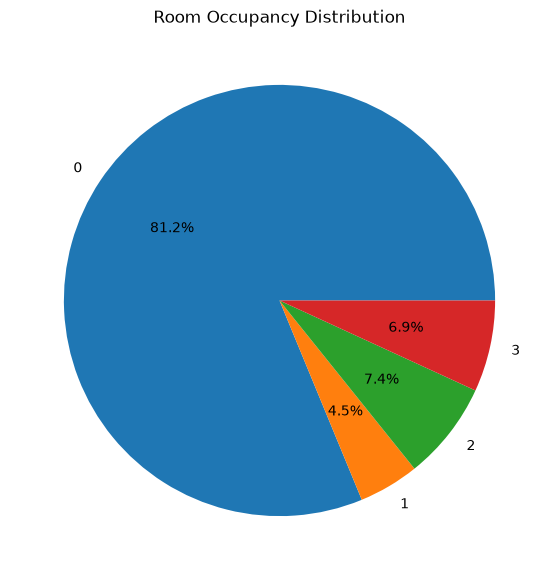

In [12]:
# Vizualization of the dataset
balance = (
    df['Room_Occupancy_Count']
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)
plt.figure(figsize=(7,7))

balance.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Room Occupancy Distribution')
plt.show()

# **2 - Data Cleaning**

In [14]:
df.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [ ]:
# 1. Correct Data Types and Convert Date/Time
# This step is important for feature engineering
df["Timestamp"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    errors="coerce"
)
# error="coerce" will convert invalid parsing to NaT (Not a Time)

df = df.sort_values("Timestamp").reset_index(drop=True)
df.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,Timestamp
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1,2017-12-22 10:49:41
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1,2017-12-22 10:50:12
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1,2017-12-22 10:50:42
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1,2017-12-22 10:51:13
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1,2017-12-22 10:51:44


#### **2. Check and Handle Missing Values**
##### **Handling Missing Values**

1. **Mean:** Use with numerical data when there are no outliers.
2. **Median:** Use with numerical data when the data contains outliers or is skewed.
3. **Mode:** Use with categorical or binary data, such as `S6_PIR` and `S7_PIR`.
4. **Drop Rows:** Remove rows when the missing value is in the target column or when very few rows are affected.

![Room Occupancy Dataset](img3.png)

In [ ]:
df.isnull().sum()

Date                    0
Time                    0
S1_Temp                 0
S2_Temp                 0
S3_Temp                 0
S4_Temp                 0
S1_Light                0
S2_Light                0
S3_Light                0
S4_Light                0
S1_Sound                0
S2_Sound                0
S3_Sound                0
S4_Sound                0
S5_CO2                  0
S5_CO2_Slope            0
S6_PIR                  0
S7_PIR                  0
Room_Occupancy_Count    0
Timestamp               0
dtype: int64

In [ ]:
# 3. Detect and Remove Duplicate Rows
print("Duplicated rows:", df.duplicated().sum())
# if data is dublicated, we can remove it using the drop_duplicates() method.
#  df = df.drop_duplicates()

Duplicated rows: 0


In [22]:
# 4. Check Invalid or Impossible Values
print(df["S6_PIR"].unique())
print(df["S7_PIR"].unique())
print(df["Room_Occupancy_Count"].unique())

[0 1]
[0 1]
[1 2 3 0]


In [ ]:
# ~ mean not  [ Select values that are NOT 0 or 1 by inverting the Boolean mask ]
invalid_pir = df[
    ~df["S6_PIR"].isin([0, 1]) |
    ~df["S7_PIR"].isin([0, 1])
]

invalid_target = df[
    ~df["Room_Occupancy_Count"].isin([0, 1, 2, 3])
]

print("Invalid PIR rows:", len(invalid_pir))
print("Invalid target rows:", len(invalid_target))

Invalid PIR rows: 0
Invalid target rows: 0


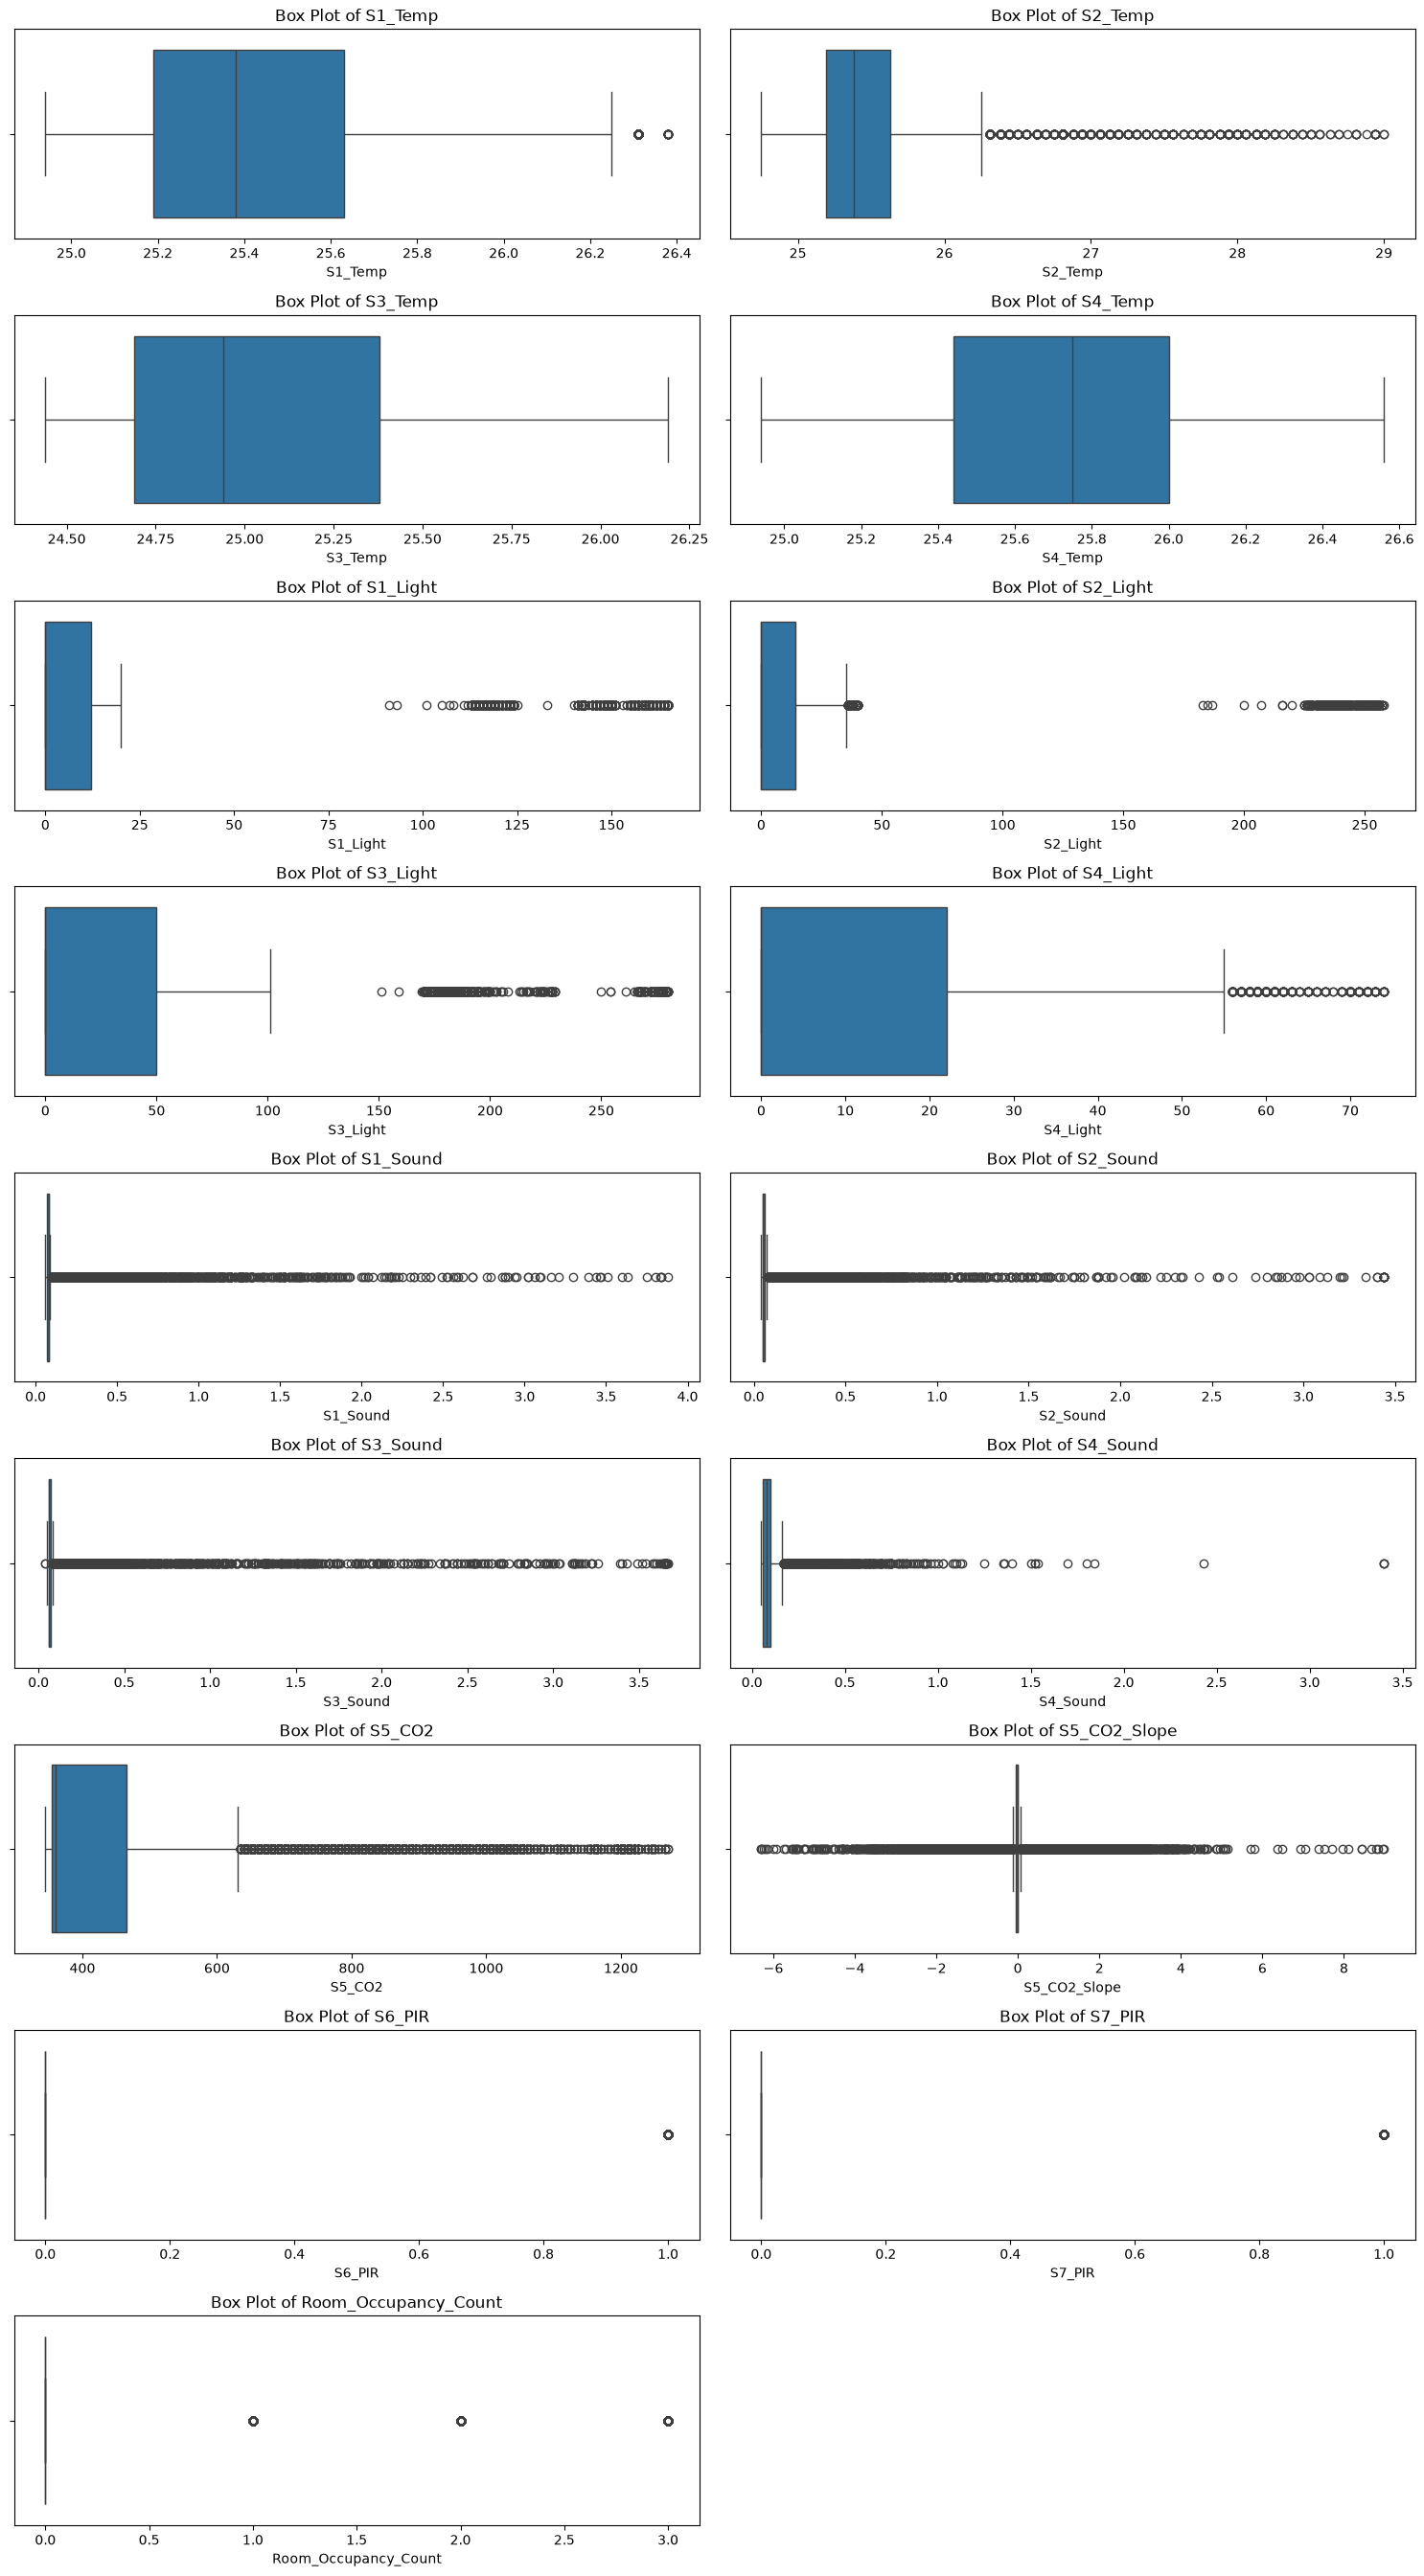

In [ ]:
# 5 - Check Outliers
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

cols = 2
rows = math.ceil(len(num_cols) / cols) # (19 /2) = 9.5 => 10

plt.figure(figsize=(15, rows * 3))

for i, feature in enumerate(num_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x=df[feature])
    plt.title(f"Box Plot of {feature}")

plt.tight_layout()
plt.show()